In [2]:
import jax
import jax.numpy as jnp

from crn_jax import models
from crn_jax.plotting import plot_species_distributions

## Setup

In [3]:
key = jax.random.PRNGKey(0)
N_REPLICATES = 1000

In [4]:
def run_and_plot_distribution(model, x0, n_steps=200):
    """Simulate one trajectory per row of ``x0`` and plot each species' empirical
    marginal distribution over time as a heatmap.

    ``x0`` is a ``(n_replicates, len(model.SPECIES))`` array of per-replicate initial
    counts.
    """
    params = model.Params.default()
    print("Params:", params.__dict__)
    n_replicates = x0.shape[0]
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0, dt=0.1, n_steps=n_steps)
    title = f"{model.__name__.rsplit('.', 1)[-1]} (N={n_replicates})"
    plot_species_distributions(dataset, title=title)

## Many-trajectory ensembles (N=1000)

Params: {'alpha': 5.0, 'delta': 1.0}


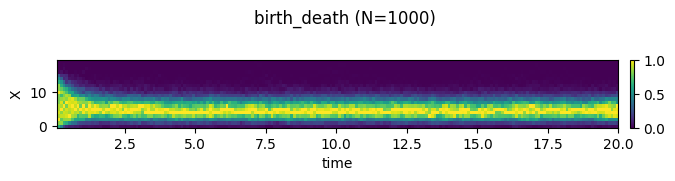

In [4]:
# Birth-death. A single species is produced at a constant rate and decays first-order;
# the stationary distribution is Poisson with mean α/δ = 5. Seeding x0 uniformly across
# {0..15} (wider than the stationary support) lets us watch every replicate relax back
# toward Poisson(5) over a few decay times (1/δ = 1) — the heatmap shows the uniform
# block at t=0 collapsing onto the Poisson band.
# Species: X (the species count).
x0 = jax.random.randint(jax.random.PRNGKey(1), (N_REPLICATES, 1), minval=0, maxval=16)
run_and_plot_distribution(models.birth_death, x0=x0)

Params: {'k_R': 0.6, 'gamma_R': 0.3466, 'k_P': 6.931, 'gamma_P': 0.01155}


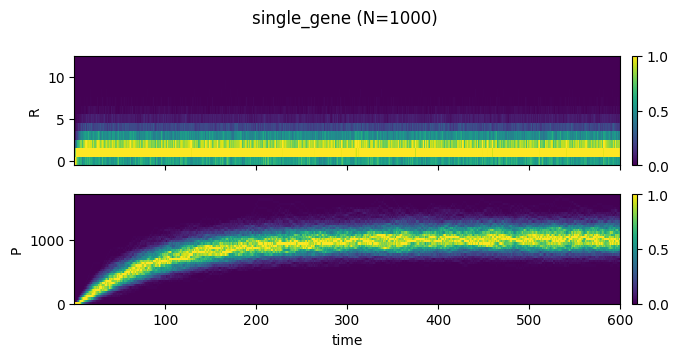

In [5]:
# Single-gene expression. Transcription produces mRNA constitutively, which is then
# translated into protein; both species decay first-order. The simplest model with a
# hidden delay between input and output.
# Species: R (mRNA), P (protein).

# Start from nothing and watch mRNA slowly increase P until steady-state
x0 = jnp.zeros((N_REPLICATES, 2))
run_and_plot_distribution(models.single_gene, x0=x0, n_steps=6000)

Params: {'beta_0': 0.0, 'beta_1': 0.05776, 'K': 1.0, 'n': 1.0, 'delta': 0.01155}


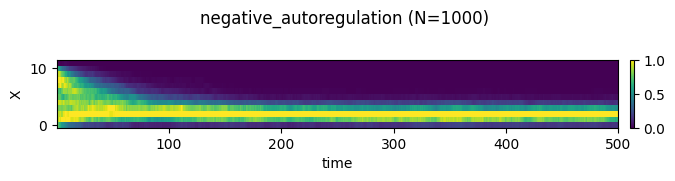

In [5]:
# Negative autoregulation. A single species represses its own production through a Hill
# term — a classic noise-reducing motif that speeds up response and tightens the
# stationary distribution compared to unregulated expression.
# Species: X (the species count).
# Seed x0 ~ Uniform{0..10} (much wider than the SS spread) to see self-repression squeeze
# the marginal down to its tight stationary distribution around ⟨X⟩ ≈ 1.79.
x0 = jax.random.randint(jax.random.PRNGKey(4), (N_REPLICATES, 1), minval=0, maxval=11)
run_and_plot_distribution(models.negative_autoregulation, x0=x0, n_steps=5000)

Params: {'beta_0': 0.005776, 'beta_1': 0.05776, 'K': 1.0, 'n': 1.0, 'delta': 0.01155}


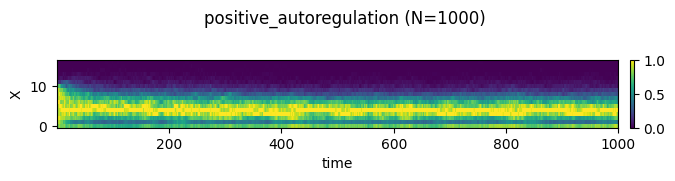

In [5]:
# Positive autoregulation. A single species activates its own production through a Hill
# term. With sub-cooperative Hill (n ≤ 1) the equilibrium is monostable and graded; with
# sharper cooperativity and low leakage the dynamics become switch-like (see bistable).
# Species: X (the species count).
# Seed x0 ~ Uniform{0..10} (much wider than the SS spread)
x0 = jax.random.randint(jax.random.PRNGKey(5), (N_REPLICATES, 1), minval=0, maxval=11)
run_and_plot_distribution(models.positive_autoregulation, x0=x0, n_steps=10000)

Params: {'beta_0': 0.01, 'beta_1': 8.0, 'K': 1.0, 'n': 2.0, 'delta': 1.0}


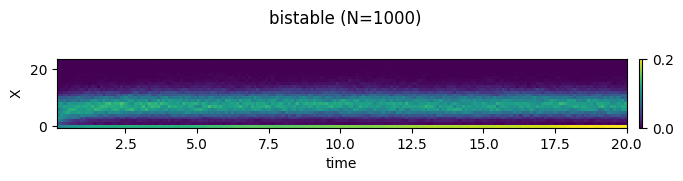

In [13]:
# Bistable self-activation. The same reactions as positive_autoreg, but parameterised in
# the bistable regime (sharper Hill exponent, lower leakage). Trajectories settle into one
# of two stable attractors, and noise can drive rare transitions between them.
# Species: X (the species count).
# Spread x0 ~ Uniform{0..10} so some replicates land below the saddle and commit to the
# low basin while others commit to the high — at SS the heatmap shows a bimodal band.
x0 = jax.random.randint(jax.random.PRNGKey(6), (N_REPLICATES, 1), minval=0, maxval=11)
run_and_plot_distribution(models.bistable, x0=x0)

Params: {'alpha_A': 5.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0}


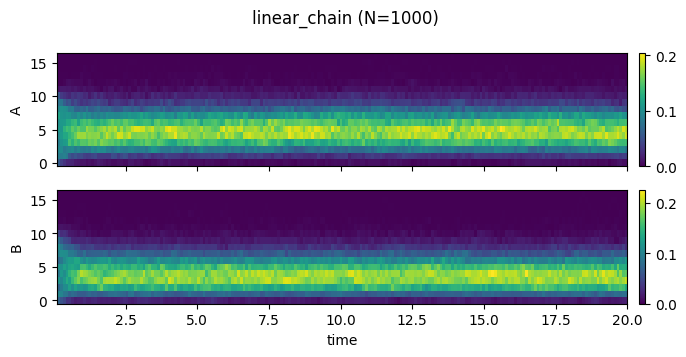

In [14]:
# Linear activation chain. A is produced at a constant rate and decays first-order;
# A then activates B through a Hill term. The simplest open signalling cascade — useful as
# a baseline for studying propagation delay and noise filtering.
# Species: A (upstream driver), B (downstream target).
x0 = jax.random.randint(jax.random.PRNGKey(7), (N_REPLICATES, 2), minval=0, maxval=11)
run_and_plot_distribution(models.linear_chain, x0=x0)

Params: {'beta_A0': 15.6, 'beta_A1': 156.25, 'beta_B0': 0.0, 'beta_B1': 15.6, 'K_A': 2.0015, 'K_B': 2.9618e-05, 'n_A': 1.0, 'n_B': 2.5, 'delta_A': 1.0, 'delta_B': 1.0}


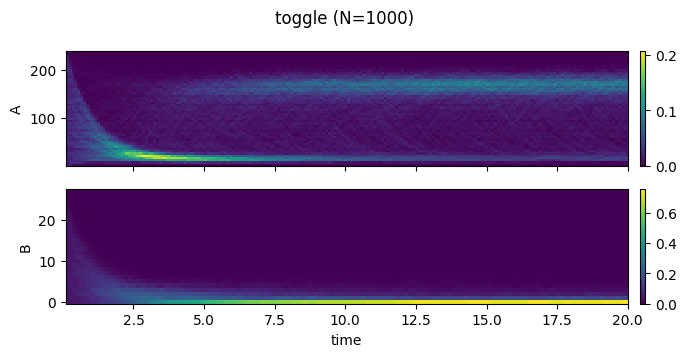

In [15]:
# Toggle switch. Two species mutually repress each other (Gardner-Cantor-Collins, 2000);
# for sharp enough Hill cooperativity the system is bistable, settling into either an
# "A-high, B-low" or "A-low, B-high" state.
# Species: A, B (mutually repressing genes).
# Spread x0 widely across both axes (A up to ~250, B up to ~25) so some replicates commit
# to each basin and the per-species marginal becomes bimodal at SS.
x0 = jax.random.randint(
    jax.random.PRNGKey(8),
    (N_REPLICATES, 2),
    minval=jnp.array([0, 0]),
    maxval=jnp.array([251, 26]),
)
run_and_plot_distribution(models.toggle, x0=x0)

Params: {'beta_A0': 0.05, 'beta_A1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0}


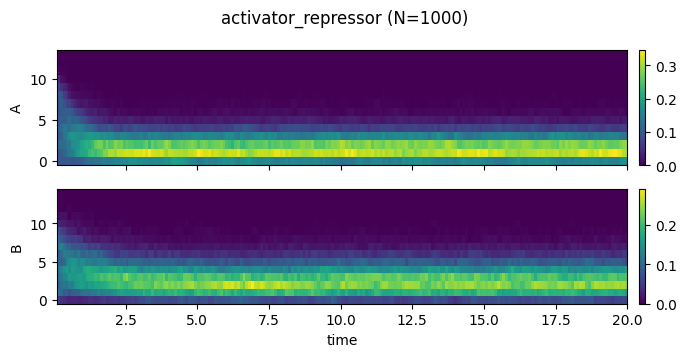

In [16]:
# Activator-repressor pair. Mixed-sign two-node feedback: A activates B and B represses A.
# For suitable parameters this circuit can produce sustained oscillations (a relaxation
# oscillator) — the simplest two-node motif that ticks.
# Species: A (activator), B (repressor).
# Note: with N=1000 replicates at random phase, the marginal heatmap smears out the
# oscillation; the per-trajectory cycle isn't directly visible here.
x0 = jax.random.randint(jax.random.PRNGKey(9), (N_REPLICATES, 2), minval=0, maxval=11)
run_and_plot_distribution(models.activator_repressor, x0=x0)

Params: {'beta_A0': 0.05, 'beta_A1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0}


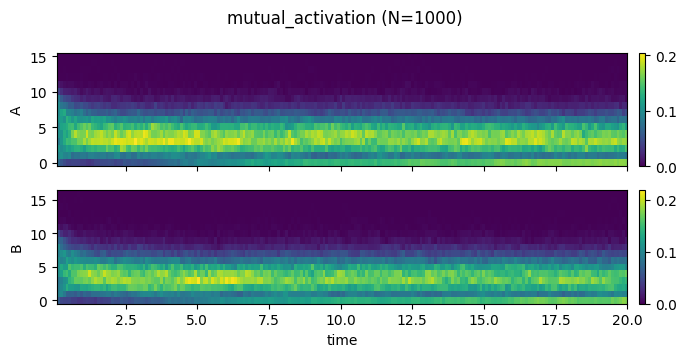

In [17]:
# Mutual activation. Two species activate each other through Hill terms. This positive
# two-node feedback can amplify small fluctuations into bistability under sharp Hill
# cooperativity.
# Species: A, B (mutually activating genes).
x0 = jax.random.randint(jax.random.PRNGKey(10), (N_REPLICATES, 2), minval=0, maxval=11)
run_and_plot_distribution(models.mutual_activation, x0=x0)

Params: {'a': 1.0, 'Ty': 0.5, 'Tz': 0.5}


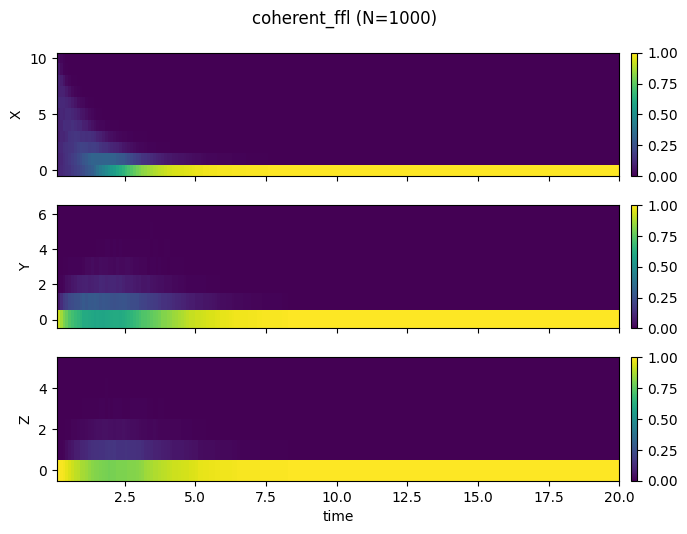

In [18]:
# Coherent feed-forward loop (AND logic). X drives Y, and X and Y together gate Z; X is
# not produced by the model (it enters as an initial condition and decays). The
# AND-gate at Z introduces a sign-sensitive delay: Z only responds to sustained X pulses.
# Species: X (input pulse), Y (intermediate), Z (output).
# Sample X ~ Uniform{0..10} so some replicates start above the threshold Ty=0.5 (driving
# Y/Z briefly before X decays below threshold) and others below (silent). Y and Z = 0.
X0 = jax.random.randint(jax.random.PRNGKey(11), (N_REPLICATES, 1), minval=0, maxval=11)
YZ0 = jnp.zeros((N_REPLICATES, 2), dtype=jnp.int32)
x0 = jnp.concatenate([X0, YZ0], axis=-1)
run_and_plot_distribution(models.coherent_ffl, x0=x0)

Params: {'alpha_A': 5.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0, 'beta_C0': 0.05, 'beta_C1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_C': 1.0}


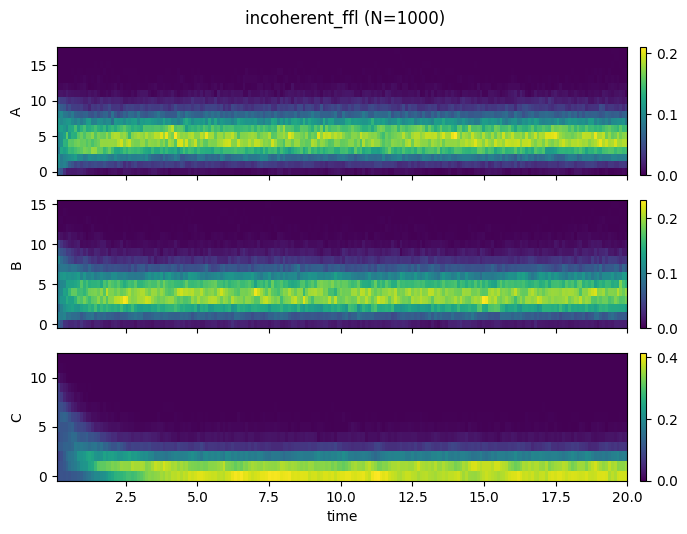

In [19]:
# Incoherent feed-forward loop. A activates both B and C, while B represses C. The opposing
# direct (A→C) and indirect (A→B⊣C) paths produce a pulse / adaptive response on C: C
# transiently rises after A turns on, then falls as the slower repression through B kicks in.
# Species: A (input), B (intermediate repressor), C (output).
x0 = jax.random.randint(jax.random.PRNGKey(12), (N_REPLICATES, 3), minval=0, maxval=11)
run_and_plot_distribution(models.incoherent_ffl, x0=x0)

Params: {'beta_A0': 0.03, 'beta_A1': 29.97, 'beta_B0': 0.03, 'beta_B1': 29.97, 'beta_C0': 0.03, 'beta_C1': 29.97, 'K_A': 40.0, 'K_B': 40.0, 'K_C': 40.0, 'n': 2.0, 'delta_A': 0.347, 'delta_B': 0.347, 'delta_C': 0.347}


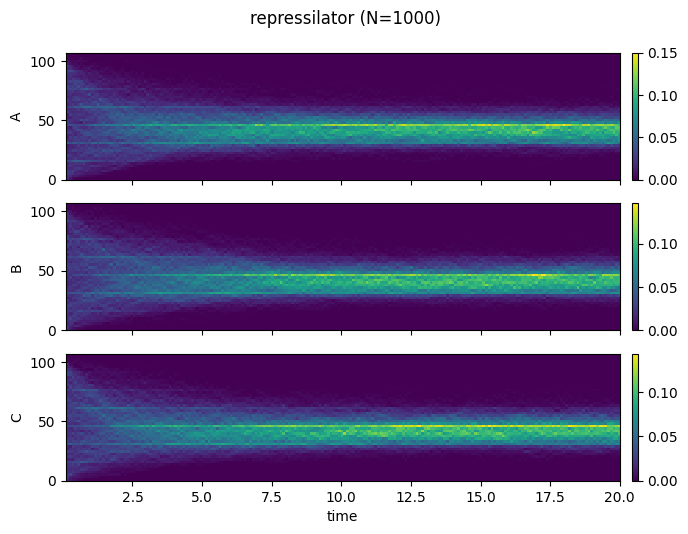

In [20]:
# Repressilator (Elowitz-Leibler, 2000). A three-node repressive ring in which A
# represses B, B represses C, and C represses A. With sufficient Hill cooperativity and a
# clear timescale separation the system enters a stable limit cycle — a synthetic oscillator.
# Species: A, B, C (the three mutually-repressing genes).
# Sample each species ~ Uniform{0..100} (around the unrepressed SS ~ β₁/δ ≈ 86). With
# random ICs across N=1000 replicates, individual trajectories cycle but the marginal
# heatmap smears out the oscillation; the per-trajectory cycle isn't directly visible here.
x0 = jax.random.randint(jax.random.PRNGKey(13), (N_REPLICATES, 3), minval=0, maxval=101)
run_and_plot_distribution(models.repressilator, x0=x0)

Params: {'beta_A0': 0.05, 'beta_A1': 5.0, 'K_C': 1.0, 'n_C': 1.0, 'delta_A': 1.0, 'beta_B0': 0.05, 'beta_B1': 5.0, 'K_A': 1.0, 'n_A': 1.0, 'delta_B': 1.0, 'beta_C0': 0.05, 'beta_C1': 5.0, 'K_B': 1.0, 'n_B': 1.0, 'delta_C': 1.0}


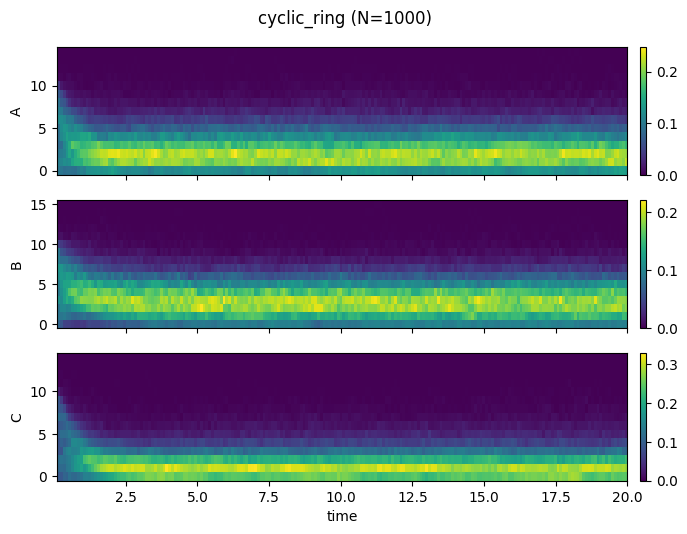

In [21]:
# Cyclic hybrid ring. A mixed-sign three-node loop in which C represses A, A activates B,
# and B represses C. The two repressors and one activator give qualitatively different
# dynamics from the pure-repressive repressilator.
# Species: A, B, C (the three species in the ring).
x0 = jax.random.randint(jax.random.PRNGKey(14), (N_REPLICATES, 3), minval=0, maxval=11)
run_and_plot_distribution(models.cyclic_ring, x0=x0)